In [1]:
import sys
import os

# In a Jupyter notebook, __file__ is not defined; use os.getcwd() for the current working directory
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_PATH = os.path.join(PROJECT_ROOT, 'src')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

os.chdir('../')
from tqdm import tqdm
import pandas as pd
import json
from src.models.config import Config
from src.supervised_runner import SupervisedRunner
from src.semi_supervised_runner import SemiSupervisedRunner
from src.self_supervised_runner import SelfSupervisedRunner
from src.utils.hyperparameter_tuning_utils import set_nested

/Users/parham/Desktop/Projects/amyloid-beta-plaque-classification/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_model(train_type, run_folder_path, load_dataloaders=False):
    if not os.path.exists(os.path.join(run_folder_path, 'config.txt')):
        raise FileNotFoundError(f"Config file not found at {os.path.join(run_folder_path, 'config.txt')}")
    config = Config.from_txt(os.path.join(run_folder_path, 'config.txt'))
    base_params = json.load(open(os.path.join(run_folder_path, 'best_params.json')))
    for key, value in base_params.items():
        set_nested(config, key, value)
    if train_type == 'supervised':
        runner = SupervisedRunner(config, 'single')
    elif train_type == 'semi_supervised':
        runner = SemiSupervisedRunner(config, 'single')
    elif train_type == 'self_supervised':
        runner = SelfSupervisedRunner(config, 'single')
    else:
        raise ValueError(f"Invalid train type: {train_type}")
    model = runner.load_model_from_checkpoint(os.path.join(run_folder_path, 'checkpoints', 'best_model.ckpt'))

    if load_dataloaders:
        if runner._type() == 'supervised':
            labeled_dataloader,_,_= runner.load_dataloaders(runner.labeled_data_df, pd.DataFrame(), pd.DataFrame(), runner.unlabeled_data_df)
            return model, labeled_dataloader
        else:
            labeled_dataloader,_,_,unlabeled_dataloader= runner.load_dataloaders(runner.labeled_data_df, pd.DataFrame(), pd.DataFrame(), runner.unlabeled_data_df)
            return model, (labeled_dataloader, unlabeled_dataloader)
    else:
        return model

In [3]:
def extract_features(feature_extractor, dataloader):
    original_extracted_features = []
    augmentations_extracted_features = []
    original_labels = []
    augmentations_labels = []
    device = next(feature_extractor.parameters()).device
    for (_image_path, is_transformed, normalized_transformed_image_tensor, _extra_features, label) in tqdm(dataloader, desc="Extracting features"):
        features = feature_extractor(normalized_transformed_image_tensor.to(device))
        for i in range(len(is_transformed)):
            if is_transformed[i]:
                augmentations_extracted_features.append(features[i].detach().cpu().numpy())
                augmentations_labels.append(label[i].cpu().numpy().item())
            else:
                original_extracted_features.append(features[i].detach().cpu().numpy())
                original_labels.append(label[i].cpu().numpy().item())
    return original_extracted_features, augmentations_extracted_features, original_labels, augmentations_labels

In [4]:

id_to_name = {"0": "Diffuse",
    "1": "Cored",
    "2": "Compact",
    "3": "Coarse",
    "4": "CAA",
    "5": "Subpial",
    "6": "OtherAB",
    "7": "UndefAB",
    "8": "NonAB"}

Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.47it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.85it/s]
Seed set to 44


...

Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:08<00:00,  8.89it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:08<00:00,  8.76it/s]


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: color
  figure: `~matplotlib.figure.Figure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 'semi-expanded', 'expanded', 'extra-expanded', 'ultra-e

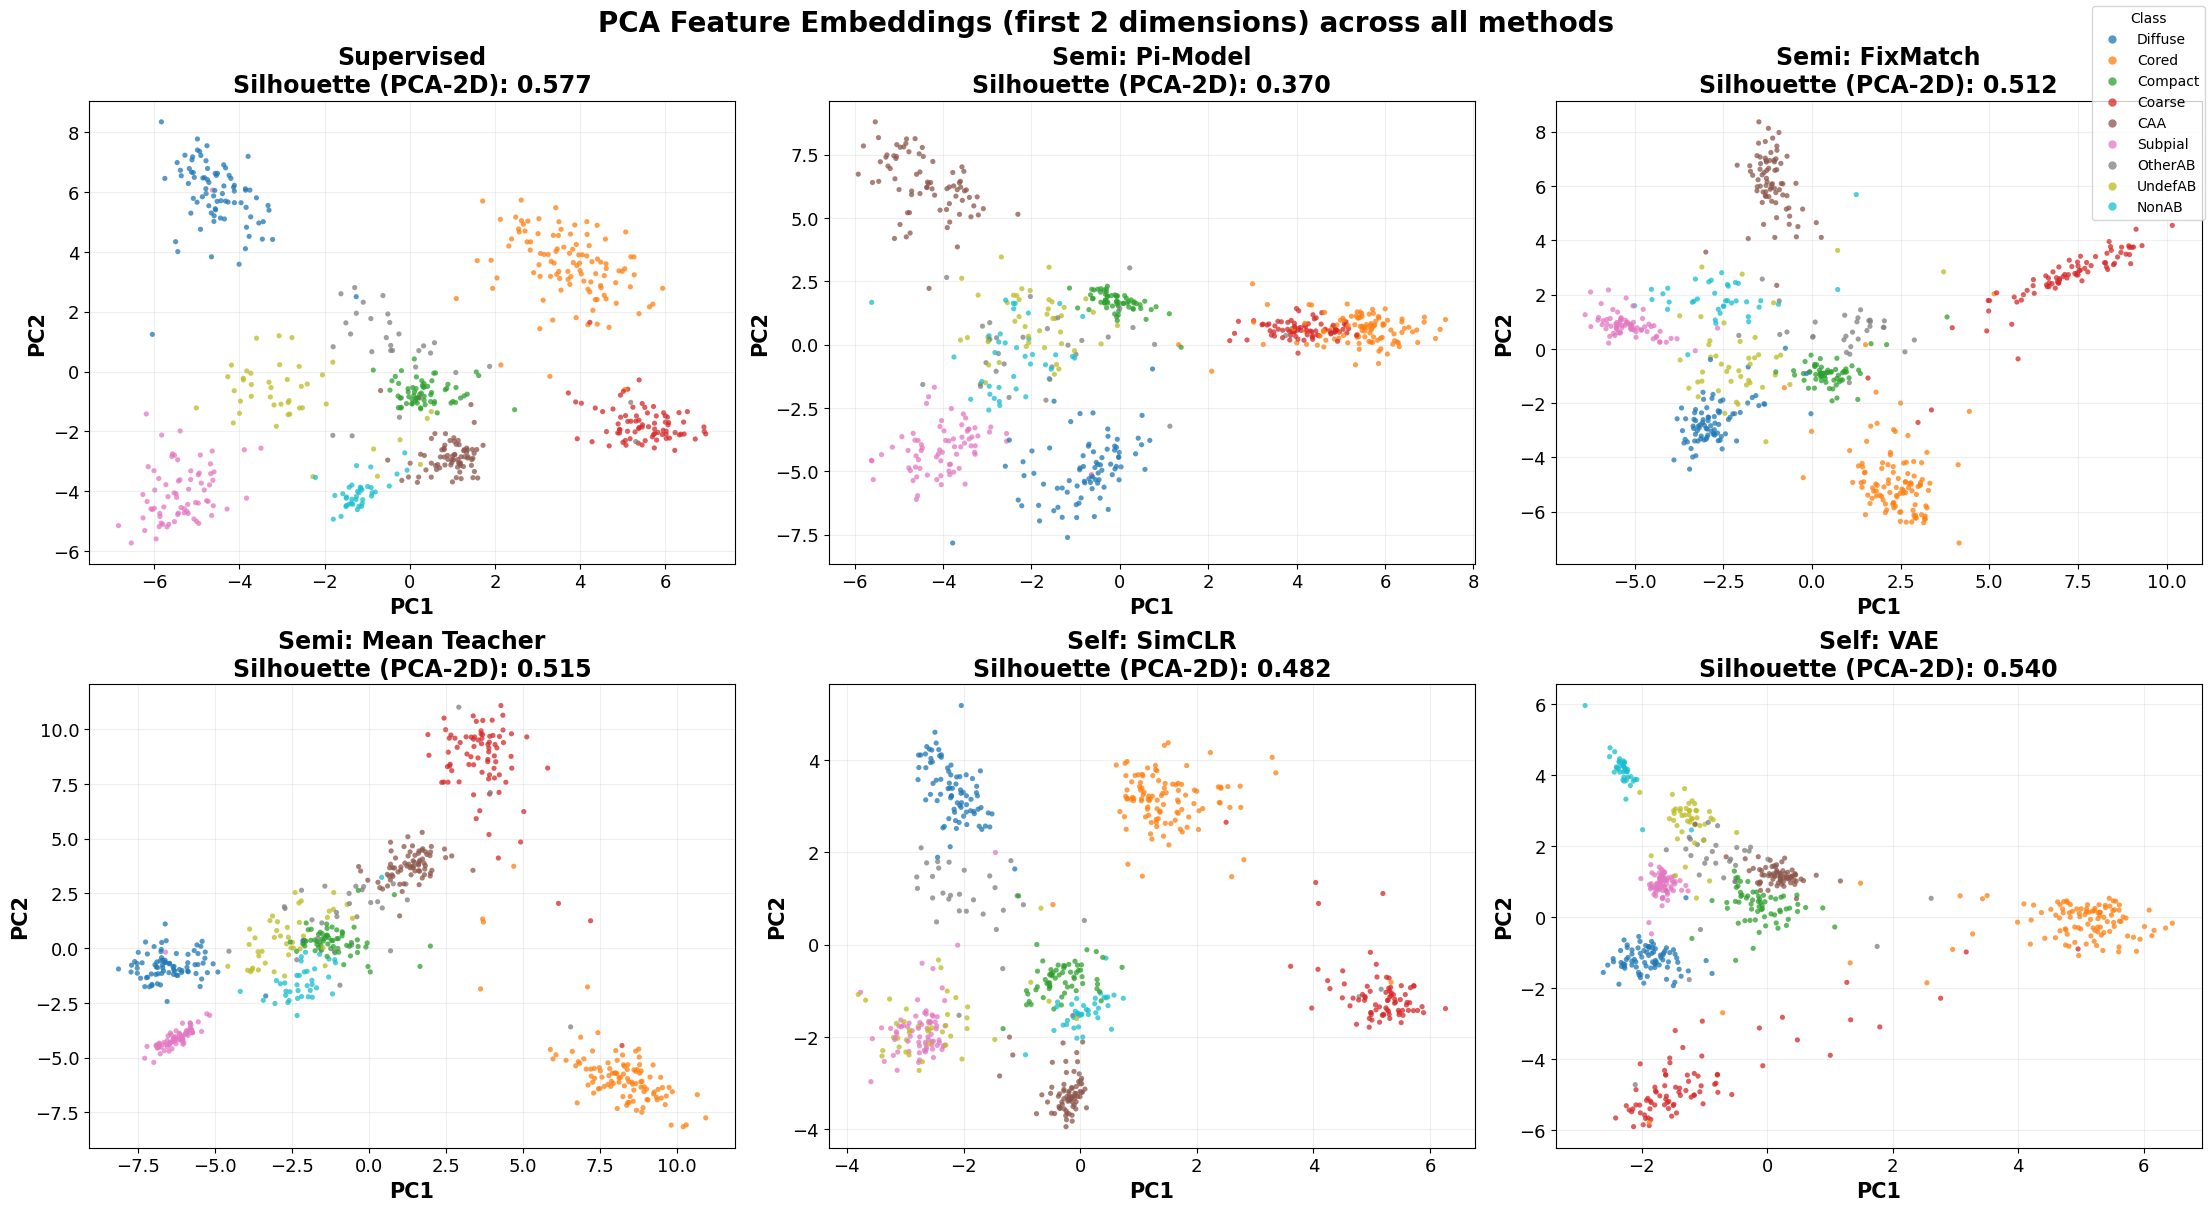

Silhouette scores (PCA 2D):
  Supervised: 0.577
  Semi: Pi-Model: 0.370
  Semi: FixMatch: 0.512
  Semi: Mean Teacher: 0.515
  Self: SimCLR: 0.482
  Self: VAE: 0.540


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Assumes load_model(...) and extract_features(...) are already defined in earlier cells.
METHOD_SPECS = [
    ("supervised", "", "Supervised"),
    ("semi_supervised", "pi_model", "Semi: Pi-Model"),
    ("semi_supervised", "fixmatch", "Semi: FixMatch"),
    ("semi_supervised", "mean_teacher", "Semi: Mean Teacher"),
    ("self_supervised", "simclr", "Self: SimCLR"),
    ("self_supervised", "vae", "Self: VAE"),
]
FEATURE_EXTRACTOR = "resnet18"


def _build_run_path(train_type, train_method, feature_extractor):
    base = f"./runs/hyperparameter_tuning/{train_type}"
    if train_type == "supervised":
        return f"{base}/{feature_extractor}"
    return f"{base}/{train_method}/{feature_extractor}"


def _safe_silhouette(X_2d, y):
    classes = np.unique(y)
    if len(classes) < 2:
        return np.nan
    return silhouette_score(X_2d, y)


fig, axes = plt.subplots(2, 3, figsize=(22, 12), constrained_layout=True)
axes = axes.flatten()

scores = {}
for ax, (train_type, train_method, label) in zip(axes, METHOD_SPECS):
    run_folder_path = _build_run_path(train_type, train_method, FEATURE_EXTRACTOR)

    loaded = load_model(train_type, run_folder_path, load_dataloaders=True)
    if train_type == "supervised":
        model, labeled_dataloader = loaded
    else:
        model, (labeled_dataloader, _unlabeled_dataloader) = loaded

    feature_extractor = model.feature_extractor.eval()
    original_features, _aug_features, original_labels, _aug_labels = extract_features(feature_extractor, labeled_dataloader)

    X = np.asarray(original_features)
    y = np.asarray(original_labels)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=44).fit_transform(X_scaled)

    s = _safe_silhouette(X_pca, y)
    scores[label] = s

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y,
        cmap="tab10",
        s=14,
        alpha=0.75,
        linewidths=0,
    )
    score_text = "nan" if np.isnan(s) else f"{s:.3f}"
    ax.set_title(
        f"{label}\nSilhouette (PCA-2D): {score_text}",
        fontsize=17, fontweight="bold"
    )
    ax.set_xlabel("PC1", fontsize=15, fontweight="bold")
    ax.set_ylabel("PC2", fontsize=15, fontweight="bold")
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.grid(alpha=0.2)

# Hide unused axes (if any)
for ax in axes[len(METHOD_SPECS):]:
    ax.axis("off")

fig.suptitle(
    "PCA Feature Embeddings (first 2 dimensions) across all methods",
    fontsize=20, fontweight="bold"
)

# Shared legend by class ids
handles, _ = scatter.legend_elements(prop="colors")
legend_labels = [id_to_name[str(i)] for i in sorted(np.unique(y))]
leg = fig.legend(
    handles, legend_labels, title="Class", loc="upper right",
    title_fontsize=10, fontsize=10, frameon=True
)
plt.setp(leg.get_title())
# for text in leg.get_texts():
#     text.set_fontweight("bold")

plt.savefig("./notebooks/feature_space_pca.pdf")
plt.show()

print("Silhouette scores (PCA 2D):")
for k, v in scores.items():
    print(f"  {k}: {('nan' if np.isnan(v) else f'{v:.3f}')}" )

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

METHOD_SPECS = [
    ("supervised", "", "Supervised"),
    ("semi_supervised", "pi_model", "Semi: Pi-Model"),
    ("semi_supervised", "fixmatch", "Semi: FixMatch"),
    ("semi_supervised", "mean_teacher", "Semi: Mean Teacher"),
    ("self_supervised", "simclr", "Self: SimCLR"),
    ("self_supervised", "vae", "Self: VAE"),
]
FEATURE_EXTRACTOR = "resnet18"


def _build_run_path(train_type, train_method, feature_extractor):
    base = f"./runs/hyperparameter_tuning/{train_type}"
    if train_type == "supervised":
        return f"{base}/{feature_extractor}"
    return f"{base}/{train_method}/{feature_extractor}"


def _safe_silhouette(X, y):
    # silhouette_score requires at least 2 classes.
    if len(np.unique(y)) < 2:
        return np.nan
    return silhouette_score(X, y)


rows = []
for train_type, train_method, model_label in METHOD_SPECS:
    run_folder_path = _build_run_path(train_type, train_method, FEATURE_EXTRACTOR)

    loaded = load_model(train_type, run_folder_path, load_dataloaders=True)
    if train_type == "supervised":
        model, labeled_dataloader = loaded
    else:
        model, (labeled_dataloader, _unlabeled_dataloader) = loaded

    feature_extractor = model.feature_extractor.eval()
    original_features, _aug_features, original_labels, _aug_labels = extract_features(feature_extractor, labeled_dataloader)

    X = np.asarray(original_features)
    y = np.asarray(original_labels)

    # Scale once for both comparisons.
    X_scaled = StandardScaler().fit_transform(X)
    X_pca2 = PCA(n_components=2, random_state=44).fit_transform(X_scaled)

    sil_pca2 = _safe_silhouette(X_pca2, y)
    sil_all = _safe_silhouette(X_scaled, y)

    rows.append(
        {
            "model": model_label,
            "silhouette_pca2": sil_pca2,
            "silhouette_all_dims": sil_all,
            "feature_dim": X.shape[1],
            "n_samples": X.shape[0],
        }
    )

silhouette_df = pd.DataFrame(rows).sort_values("silhouette_all_dims", ascending=False).reset_index(drop=True)

# Rounded view for easier visual comparison.
display_df = silhouette_df.copy()
display_df["silhouette_pca2"] = display_df["silhouette_pca2"].round(3)
display_df["silhouette_all_dims"] = display_df["silhouette_all_dims"].round(3)

display(display_df)

# Optional CSV export if needed later.
# display_df.to_csv("notebooks/feature_space_silhouette_comparison.csv", index=False)

Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.31it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:07<00:00,  9.70it/s]
Seed set to 44


...

Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:08<00:00,  8.79it/s]
Seed set to 44


Random seeds set to 44 for reproducibility


Extracting features: 100%|██████████| 74/74 [00:08<00:00,  8.55it/s]


,model,silhouette_pca2,silhouette_all_dims,feature_dim,n_samples
0,Self: VAE,0.540,0.700,32,589
1,Self: SimCLR,0.482,0.690,32,589
2,Semi: Mean Teacher,0.515,0.662,128,589
3,Semi: FixMatch,0.512,0.642,64,589
4,Supervised,0.577,0.613,64,589
5,Semi: Pi-Model,0.370,0.578,64,589


In [7]:
if 'n_samples' in display_df.columns:
    display_df.drop('n_samples', axis=1, inplace=True)
display_df.sort_values("model", inplace=True, ascending=False)
display_df.to_csv("notebooks/feature_space_silhouette_comparison.csv", index=False)
display(display_df)

,model,silhouette_pca2,silhouette_all_dims,feature_dim
4,Supervised,0.577,0.613,64
5,Semi: Pi-Model,0.370,0.578,64
2,Semi: Mean Teacher,0.515,0.662,128
3,Semi: FixMatch,0.512,0.642,64
0,Self: VAE,0.540,0.700,32
1,Self: SimCLR,0.482,0.690,32
